Step 1: Loading, Quality Control, and Data Cleaning

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual style setting
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Loading the dataset
df = pd.read_csv('insurance.csv')

# 2. Initial inspection
print("--- FIRST 5 LINES ---")
print(df.head())

print("\n--- DATASET INFORMATION ---")
print(df.info())

print("\n--- CHECK FOR NULL AND DUPLICATE VALUES ---")
print(f"Null values ​​per column:\n{df.isnull().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

# Cleanup: Remove any duplicate rows if present
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("-> Duplicates successfully removed.")

# 3. Descriptive statistics
print("\n--- DESCRIPTIVE STATISTICS (NUMERICAL) ---")
print(df.describe().round(2))

--- FIRST 5 LINES ---
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

--- DATASET INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

--- CHECK FOR NULL AND DUPLICATE VALUES

Step 2: Graphical Analysis (Data Storytelling)

Chart 1: Distribution of the Target variable (charges)

Shows how costs are not normally distributed, but have a positive skew (right-tailed).

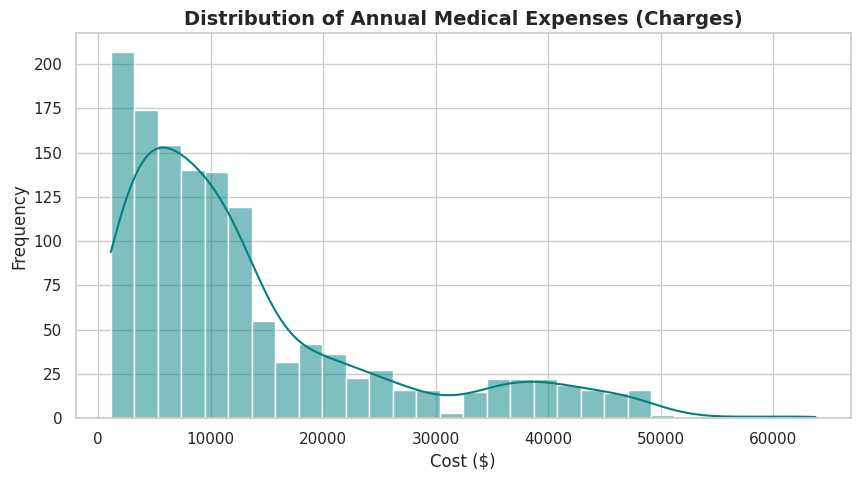

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df['charges'], kde=True, color='teal', bins=30)
plt.title('Distribution of Annual Medical Expenses (Charges)', fontsize=14, fontweight='bold')
plt.xlabel('Cost ($)')
plt.ylabel('Frequency')
plt.show()

Chart 2: The Combined Effect of Smoking and BMI (The “Killer Insight”)

This chart makes clear the multiplicative impact between obesity (BMI ≥ 30) and smoking.

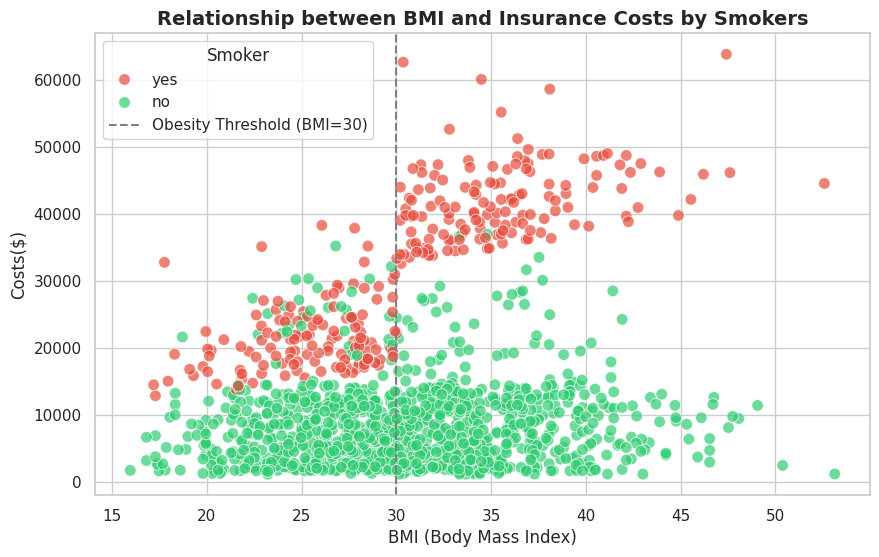

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='bmi',
    y='charges',
    hue='smoker',
    palette={'yes': '#e74c3c', 'no': '#2ecc71'},
    alpha=0.7,
    s=70
)
# Obesity cutoff line (BMI = 30)
plt.axvline(30, color='grey', linestyle='--', label='Obesity Threshold (BMI=30)')

plt.title('Relationship between BMI and Insurance Costs by Smokers', fontsize=14, fontweight='bold')
plt.xlabel('BMI (Body Mass Index)')
plt.ylabel('Costs($)')
plt.legend(title='Smoker')
plt.show()

Chart 3: Average Cost by Age Category and Smoking

Age groups are created to observe spending trends over time.

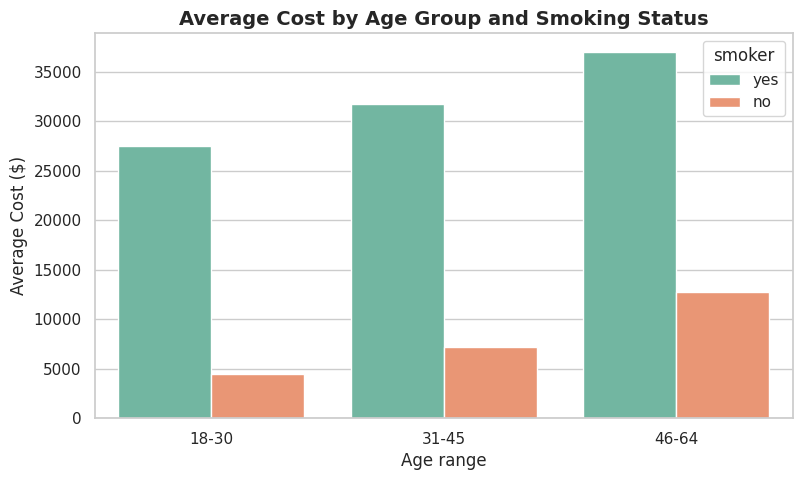

In [10]:
# Creating age groups
df['age_group'] = pd.cut(df['age'], bins=[17, 30, 45, 65], labels=['18-30', '31-45', '46-64'])

plt.figure(figsize=(9, 5))
sns.barplot(
    data=df,
    x='age_group',
    y='charges',
    hue='smoker',
    palette='Set2',
    errorbar=None
)
plt.title('Average Cost by Age Group and Smoking Status', fontsize=14, fontweight='bold')
plt.xlabel('Age range')
plt.ylabel('Average Cost ($)')
plt.show()

The goal is to ***train a model*** capable of predicting the insurance cost (charges) for a new customer based on their characteristics (age, BMI, smoker, etc.).

Mathematical models only work with numbers, so we need to transform the text variables (sex, smoker, region) into numeric values:

**Smoker and sex**: They have only two categories; we use Binary Encoding (0/1).

**Region**: They have four categories with no hierarchical order; we use One-Hot Encoding (pd.get_dummies).

**BMI-Smoking Interaction:** it must be created a special column that multiplies smoking by BMI, capturing the exponential effect discovered in the previous step.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Copy of the clean dataframe
df_ml = df.drop(columns=['age_group'], errors='ignore').copy()

# 2. Encoding of binary variables (0 o 1)
df_ml['smoker_code'] = df_ml['smoker'].map({'yes': 1, 'no': 0})
df_ml['sex_code'] = df_ml['sex'].map({'male': 1, 'female': 0})

# 3. Interaction features (BMI * Smoker) -> Ours "Killer Feature"
df_ml['bmi_smoker_interaction'] = df_ml['bmi'] * df_ml['smoker_code']

# 4. One-Hot Encoding for the region
df_ml = pd.get_dummies(df_ml, columns=['region'], drop_first=True, dtype=int)

# 5. Separation of Features (X) and Target (y)
X = df_ml.drop(columns=['charges', 'smoker', 'sex'])
y = df_ml['charges']

# 6. Split Train Set (80%) and Test Set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set Size: {X_train.shape[0]} lines")
print(f"Test Set Size: {X_test.shape[0]} lines")

Training Set Size: 1069 lines
Test Set Size: 268 lines


Model Training and Comparison
Three models are compared to see which offers the best accuracy:

**Linear Regression**: The simple and interpretable baseline model.

**Decision Tree Regressor**: Captures nonlinear relationships.

***Random Forest Regressor***: A set of decision trees, (my model).

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# Initialization of the three models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
}

# Dictionary to save results
results = []

for name, model in models.items():
    # Train Set Training
    model.fit(X_train, y_train)

    # Test Set Prediction
    y_pred = model.predict(X_test)

    # Calculating metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE ($)": round(mae, 2),
        "RMSE ($)": round(rmse, 2),
        "R² Score": round(r2, 3)
    })

# Summary table of results
results_df = pd.DataFrame(results)
print("--- MODEL PERFORMANCE COMPARISON ---")
print(results_df.to_string(index=False))

--- MODEL PERFORMANCE COMPARISON ---
            Model  MAE ($)  RMSE ($)  R² Score
Linear Regression  2828.97   4572.81     0.886
    Decision Tree  2681.69   4464.43     0.892
    Random Forest  2429.78   4285.45     0.900


**R^2  Score**: it measures how much of the insurance cost we can explain with the information we have (age, BMI, smoking, etc.). The closer it is to 1.0 the more accurate the model is.


**MAE (Mean Absolute Error)**: It answers the question: "On average, by how many dollars is my estimate off?". It represents the average error in dollars. An MAE of ~ 2,500 do means that, on average, the model's estimate is off by  2,500.In the dataset, insurance policies range from about 1,000 to over 60,000 per year. If an insurance company calculated prices by simply averaging across all customers (~13,270), the average error on the estimates would be about 9,000. For an insurance company, reducing the error from 9,000 to 2,500 means avoiding underestimating risks and preventing major financial losses.